# Dataset A – Adult Income



In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import StratifiedKFold, learning_curve, cross_validate
from sklearn.metrics import confusion_matrix


SEED=49
np.random.seed(SEED)
random.seed(SEED)

### Data Loading

We load the Adult Income dataset and inspect its basic structure.

In [3]:
DATA_PATH = "../adult.csv"
df = pd.read_csv(DATA_PATH)

df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
4,34.0,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,<=50K


If we look closely, `education` and `education-num` are redundant because they contain the same information, expressed in two different ways. For the purposes of creating the model, it would be best to omit one of them. We have decided to omit `education`, since `education-num` is a variable that is already numerical, which although it refers to categories, since there are many categories it will be better to treat it as numerical. 

The feature `fnlwgt` represents a census sampling weight rather than an individual-level attribute. Since our goal is predictive modeling at the individual level, this variable does not carry meaningful explanatory information and is excluded from the feature set.

### Target Variable Distribution

We analyze class balance to motivate metric selection.

In [4]:
target_col = "class"
df[target_col].value_counts()

<=50K    34014
>50K     11208
Name: class, dtype: int64

Because the adults dataset is unbalanced, accuracy may overestimate performance in the majority class. Therefore, we adopt F1 as the primary evaluation metric.

## Experiments


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

X = df.drop(columns=["class", "fnlwgt", "education"])
y = df["class"]

num_cols = ["age", "hours-per-week", "capital-gain", "capital-loss", 'education-num']
cat_cols = ['workclass','marital-status','occupation','relationship','race','sex','native-country']

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)


70% training set, 20% testing set, 10% validation set

In [6]:
from sklearn.model_selection import train_test_split

y_bin = (pd.Series(y).astype(str).str.strip() == ">50K").astype(int).values

TEST_SIZE = 0.20
VAL_SIZE  = 0.10

X_train_t, X_test, y_train_t, y_test = train_test_split(
    X, y_bin, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

val_size_within_train = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_t, y_train_t, test_size=val_size_within_train, stratify=y_train_t, random_state=SEED
)

### Neural Network

#### PyTorch + SVD

In [7]:
import torch

X_train_sp = preprocessor.fit_transform(X_train)
X_val_sp   = preprocessor.transform(X_val)
X_test_sp  = preprocessor.transform(X_test)

X_train_nn = X_train_sp.toarray() if hasattr(X_train_sp, "toarray") else np.asarray(X_train_sp)
X_val_nn   = X_val_sp.toarray()   if hasattr(X_val_sp, "toarray")   else np.asarray(X_val_sp)
X_test_nn  = X_test_sp.toarray()  if hasattr(X_test_sp, "toarray")  else np.asarray(X_test_sp)

X_train_nn = X_train_nn.astype(np.float32, copy=False)
X_val_nn   = X_val_nn.astype(np.float32, copy=False)
X_test_nn  = X_test_nn.astype(np.float32, copy=False)

X_train_nn_t = torch.from_numpy(X_train_nn)
X_val_nn_t   = torch.from_numpy(X_val_nn)
X_test_nn_t  = torch.from_numpy(X_test_nn)

y_train_nn = torch.tensor(y_train, dtype=torch.long)
y_val_nn   = torch.tensor(y_val,   dtype=torch.long)
y_test_nn  = torch.tensor(y_test,  dtype=torch.long)

input_dim = X_train_nn_t.shape[1]

In [8]:
import torch
import torch.nn as nn

class MLP_tmp(nn.Module):
    """
    MLP for binary classification
    """
    def __init__(self, d, h):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(d, h),
            nn.ReLU()
        )
        self.classifier = nn.Linear(h, 2)

    def forward(self, x):
        """
        Perform a forward pass through the network

        Input:
            x (torch.Tensor): input batch of shape (batch_size, d)

        Return:
            torch.Tensor: raw logits of shape (batch_size, 2)
        """
        return self.classifier(self.features(x))

    def freeze_all(self):
        """
        Freeze all model parameters

        Input: None

        Return:None
        """
        for p in self.parameters():
            p.requires_grad = False

    def unfreeze_last_k(self, k=1):
        """
        Unfreeze the last k logical layers of the network

        Input:
            k (int): number of layers from the output backward to unfreeze

        Return: None
        """
        self.freeze_all()
        for p in self.classifier.parameters():
            p.requires_grad = True
        if k >= 2:
            for m in self.features:
                if isinstance(m, nn.Linear):
                    for p in m.parameters():
                        p.requires_grad = True
                        
    def count_trainable_params(self):
        """
        Count the number of trainable parameters

        Input: None

        Return:
            int: total number of parameters with requires_grad = True
        """
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import time
from sklearn.metrics import accuracy_score, f1_score

import gc
gc.collect()

np.random.seed(SEED)
random.seed(SEED)

BATCH_SIZE = 64

train_ds = TensorDataset(X_train_nn_t, y_train_nn)
val_ds   = TensorDataset(X_val_nn_t,   y_val_nn)
test_ds  = TensorDataset(X_test_nn_t,  y_test_nn)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLP_tmp(d=input_dim, h=128).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def eval_f1(model, loader):
    """
    Compute F1 score for a PyTorch model

    Input:
        model (torch.nn.Module): trained neural network model
        loader (DataLoader): DataLoader providing evaluation batches

    Return:
        float: F1 score computed on the provided dataset
    """
    preds, ys = [], []

    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(next(model.parameters()).device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)

            preds.append(pred.cpu().numpy())
            ys.append(yb.cpu().numpy())

    return f1_score(np.concatenate(ys), np.concatenate(preds))


def eval_loss(model, loader):
    """
    Compute average loss

    Input:
        model (torch.nn.Module): trained neural network model
        loader (DataLoader): DataLoader providing evaluation batches

    Return:
        float: average loss computed across all samples in the dataset
    """
    total, n = 0.0, 0
    model.eval()
    
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            bs = yb.size(0)
            total += loss.item() * bs
            n += bs
    return total / n


grad_evals = 0
t0 = time.time()

for epoch in range(10):  
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        grad_evals += 1
    vloss = eval_loss(model, val_loader)
    vf1   = eval_f1(model, val_loader)
    print(f"epoch {epoch:02d} | val_loss={vloss:.4f} | val_f1={vf1:.4f} | grad_evals={grad_evals} | time={time.time()-t0:.1f}s")



2026-03-05 18:40:21.648646: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


epoch 00 | val_loss=0.3200 | val_f1=0.6876 | grad_evals=495 | time=1.0s
epoch 01 | val_loss=0.3178 | val_f1=0.6910 | grad_evals=990 | time=1.8s
epoch 02 | val_loss=0.3166 | val_f1=0.6862 | grad_evals=1485 | time=2.6s
epoch 03 | val_loss=0.3163 | val_f1=0.6861 | grad_evals=1980 | time=3.2s
epoch 04 | val_loss=0.3162 | val_f1=0.6940 | grad_evals=2475 | time=3.9s
epoch 05 | val_loss=0.3165 | val_f1=0.6985 | grad_evals=2970 | time=4.6s
epoch 06 | val_loss=0.3161 | val_f1=0.7035 | grad_evals=3465 | time=5.3s
epoch 07 | val_loss=0.3208 | val_f1=0.6764 | grad_evals=3960 | time=6.1s
epoch 08 | val_loss=0.3191 | val_f1=0.6756 | grad_evals=4455 | time=6.8s
epoch 09 | val_loss=0.3171 | val_f1=0.6939 | grad_evals=4950 | time=7.7s


In [10]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

@torch.no_grad()
def evaluate_binary(model, loader, device="cpu"):
    """
    Evaluate a binary classification model

    Input:
        model (torch.nn.Module): trained neural network model
        loader (DataLoader): DataLoader providing evaluation batches
        device (str or torch.device): device on which the model is evaluated

    Return:
        dict: dictionary containing the accuracy, F1 score, confusion matrix and predicted class labels
    """
    model.eval()
    preds, ys = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.append(torch.argmax(logits, dim=1).cpu().numpy())
        ys.append(yb.cpu().numpy())
    y_pred = np.concatenate(preds)
    y_true = np.concatenate(ys)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred
    }

In [11]:
res = evaluate_binary(model, val_loader, device=device)
print("Accuracy:", res["accuracy"])
print("F1:", res["f1"])
print("Confusion matrix:\n", res["cm"])

Accuracy: 0.8558478885695335
F1: 0.6938967136150235
Confusion matrix:
 [[3132  270]
 [ 382  739]]


In [12]:
import copy
baseline_state = copy.deepcopy(model.state_dict())

## PART 1

### Hypothesis

Because the last layers of a trained backbone are closer to a near-convex classification head, we expect randomized optimization to sometimes find slightly better “tail” validation loss than local gradient updates restricted to the same layers. However, under strict function evaluation budgets, RO methods should be less sample-efficient and show higher variance across seeds. We expect:
- GA to be the most capable of escaping shallow local minima
- SA to depend strongly on its cooling schedule
- RHC to plateau early unless restarts are used

In [13]:
PARAM_CAP = 50_000

def prepare_last_k(model, k):
    """
    Reset the model to the baseline weights and unfreeze the last k layers

    Input:
        model (torch.nn.Module): neural network model to modify
        k (int): number of last layers to unfreeze

    Return:
        int: number of trainable parameters after unfreezing last k layers
    """
    model.load_state_dict(baseline_state)   
    model.unfreeze_last_k(k=k)              
    tp = model.count_trainable_params()
    return tp

for k in [1, 2]:
    tp = prepare_last_k(model, k)
    print(f"k={k} -> trainable params = {tp}")


chosen_k = None
for k in [2, 1]:
    tp = prepare_last_k(model, k)
    if tp <= PARAM_CAP:
        chosen_k = k
        trainable_params = tp
        break

print(f"Chosen k={chosen_k} with trainable params={trainable_params} (cap={PARAM_CAP})")

k=1 -> trainable params = 258
k=2 -> trainable params = 11522
Chosen k=2 with trainable params=11522 (cap=50000)


In [14]:
def get_trainable_tensors(model):
    """
    Retrieve all trainable parameter tensors from a model

    Input:
        model (torch.nn.Module): neural network model

    Return:
        list[torch.Tensor]: list of parameters with requires_grad = True
    """
    return [p for p in model.parameters() if p.requires_grad]

def flatten_trainable(model):
    """
    Flatten all trainable parameters into a single 1D vector

    Input:
        model (torch.nn.Module): neural network model

    Return:
        torch.Tensor: flattened 1D vector of all trainable parameters
    """
    vec = torch.cat([p.detach().flatten() for p in get_trainable_tensors(model)], dim=0)
    return vec.to(device)

@torch.no_grad()
def assign_flattened_trainable(model, flat_vec):
    """
    Assign a flattened parameter vector back to the model's trainable parameters
    
    Input:
        model (torch.nn.Module): neural network model
        flat_vec (torch.Tensor): flattened parameter vector

    Return: None
    """
    flat_vec = flat_vec.detach().to(device)
    idx = 0
    for p in get_trainable_tensors(model):
        n = p.numel()
        chunk = flat_vec[idx:idx+n].view_as(p)
        p.copy_(chunk)
        idx += n
    assert idx == flat_vec.numel()

    
class ROObjective:
    """
    Objective wrapper for Randomized Optimization
    """
    
    def __init__(self, model, val_loader):
        self.model = model
        self.val_loader = val_loader
        self.fevals = 0

    @torch.no_grad()
    def __call__(self, flat_vector):
        """
        Evaluate validation loss for a given parameter vector

        Input:
            flat_vector (torch.Tensor): flattened parameter vector

        Return:
            float: validation loss value
        """
        self.fevals += 1
        assign_flattened_trainable(self.model, flat_vector)
        return float(eval_loss(self.model, self.val_loader))

In [15]:
model.load_state_dict(baseline_state)
model.unfreeze_last_k(k=chosen_k)

x0 = flatten_trainable(model)
obj = ROObjective(model, val_loader)

y0 = obj(x0)
print("RO dim:", x0.numel())
print("Initial val loss:", y0, "| fevals:", obj.fevals)

RO dim: 11522
Initial val loss: 0.31708439851845627 | fevals: 1


### RHC

In [16]:
import math

def set_all_seeds(seed):
    """
    Set random seeds for full reproducibility
    
    Input:
        seed (int): random seed value
    
    Return: None
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def rhc(obj, x_init, max_fevals=8000, restarts=10, sigma_init=0.02, sigma_decay=0.999, seed=49):
    """
    RHC with restarts and step-size decay
    
    Input:
        obj (callable): objective function returning validation loss
        x_init (torch.Tensor): initial solution vector
        max_fevals (int): maximum number of function evaluations allowed
        restarts (int): number of restart attempts
        sigma_init (float): initial Gaussian perturbation scale
        sigma_decay (float): multiplicative decay applied to sigma each step
        seed (int): random seed for reproducibility

    Return:
        best_x (torch.Tensor): best solution found
        best_y (float): best objective value (validation loss)
        hist (pd.DataFrame): history containing function evaluation count, best-so-far validation loss, elapsed time in seconds
    """
    
    set_all_seeds(seed)
    start = time.time()

    best_x = x_init.clone()
    best_y = obj(best_x)

    history = [(obj.fevals, best_y, time.time()-start)]

    per_restart = max(1, (max_fevals - obj.fevals) // restarts)

    for r in range(restarts):
        if obj.fevals >= max_fevals:
            break

        x = best_x + torch.randn_like(best_x) * (sigma_init * 2.0)
        y = obj(x)
        sigma = sigma_init

        local_best_x, local_best_y = x.clone(), y

        steps = 0
        while obj.fevals < max_fevals and steps < per_restart:
            x_prop = x + torch.randn_like(x) * sigma
            y_prop = obj(x_prop)

            if y_prop < y:
                x, y = x_prop, y_prop
                if y < local_best_y:
                    local_best_x, local_best_y = x.clone(), y

            sigma *= sigma_decay
            steps += 1

            if local_best_y < best_y:
                best_x, best_y = local_best_x.clone(), local_best_y

            history.append((obj.fevals, best_y, time.time()-start))

    hist = pd.DataFrame(history, columns=["fevals", "best_val_loss", "time_s"])
    return best_x, best_y, hist

### SA

In [17]:
def sa(obj, x_init, max_fevals = 8000, T0 = 1.0, alpha = 0.999, sigma_init = 0.02, sigma_decay = 0.9995, seed = 49):
    """
    SA with exponential temperature cooling and Gaussian perturbations

    Input:
        obj (callable): objective function returning validation loss
        x_init (torch.Tensor): initial solution vector
        max_fevals (int): maximum number of function evaluations allowed
        T0 (float): initial temperature
        alpha (float): multiplicative temperature decay factor 
        sigma_init (float): initial Gaussian perturbation scale
        sigma_decay (float): multiplicative decay for perturbation scale
        seed (int): random seed for reproducibility

    Return:
        best_x (torch.Tensor): best solution found
        best_y (float): best objective value (validation loss)
        hist (pd.DataFrame): history containing function evaluation count, best-so-far validation loss, elapsed time in seconds
    """
    set_all_seeds(seed)
    start = time.time()

    x = x_init.clone()
    y = obj(x)

    best_x, best_y = x.clone(), y
    T = T0
    sigma = sigma_init

    history = [(obj.fevals, best_y, time.time() - start)]

    while obj.fevals < max_fevals:
        x_prop = x + torch.randn_like(x) * sigma
        y_prop = obj(x_prop)

        if y_prop < y:
            accept = True
        else:
            delta = y_prop - y
            accept_prob = math.exp(-delta / max(T, 1e-12))
            accept = (random.random() < accept_prob)

        if accept:
            x, y = x_prop, y_prop
            if y < best_y:
                best_x, best_y = x.clone(), y

        T *= alpha
        sigma *= sigma_decay

        history.append((obj.fevals, best_y, time.time() - start))

    hist = pd.DataFrame(history, columns=["fevals", "best_val_loss", "time_s"])
    return best_x, best_y, hist

### GA

In [18]:
import time, random
import numpy as np
import pandas as pd
import torch

def ga(obj, x_init, max_fevals = 8000, pop_size = 40, elite_frac = 0.10, tournament_k = 3, crossover_rate = 0.6, mutation_rate = 0.2, mutation_sigma = 0.02, seed = 49):
    """
    GA with elitism, tournament selection, uniform crossover and Gaussian mutation

    Input:
        obj (callable): objective function returning validation loss
        x_init (torch.Tensor): initial solution vector
        max_fevals (int): maximum number of function evaluations allowed
        pop_size (int): population size
        elite_frac (float): fraction of top individuals preserved each generation
        tournament_k (int): tournament size for parent selection
        crossover_rate (float): probability of applying crossover
        mutation_rate (float): probability of mutating each offspring
        mutation_sigma (float): standard deviation of Gaussian mutation
        seed (int): random seed for reproducibility

    Return:
        tuple:
        best_x (torch.Tensor): best solution found
        best_y (float): best objective value (validation loss)
        hist (pd.DataFrame): history containing function evaluation count, best-so-far validation loss, elapsed time in seconds
    """
    set_all_seeds(seed)
    
    start = time.time()
    dim = x_init.numel()
    elite_n = max(1, int(pop_size * elite_frac))

    pop = [x_init + torch.randn_like(x_init) * mutation_sigma for _ in range(pop_size)]
    fits = [obj(ind) for ind in pop]

    best_idx = int(np.argmin(fits))
    best_x = pop[best_idx].clone()
    best_y = float(fits[best_idx])

    history = [(obj.fevals, best_y, time.time() - start)]

    while obj.fevals < max_fevals:

        order = np.argsort(fits)
        new_pop = [pop[i].clone() for i in order[:elite_n]]

        while len(new_pop) < pop_size and obj.fevals < max_fevals:

            idxs = np.random.choice(len(pop), size=tournament_k, replace=False)
            best_i = idxs[0]
            for i in idxs[1:]:
                if fits[i] < fits[best_i]:
                    best_i = i
            p1 = pop[best_i]

            idxs = np.random.choice(len(pop), size=tournament_k, replace=False)
            best_i = idxs[0]
            for i in idxs[1:]:
                if fits[i] < fits[best_i]:
                    best_i = i
            p2 = pop[best_i]

            if random.random() < crossover_rate:
                mask = torch.rand(dim, device=x_init.device) < 0.5
                c1 = torch.where(mask, p1, p2)
                c2 = torch.where(mask, p2, p1)
            else:
                c1 = p1.clone()
                c2 = p2.clone()

            if random.random() < mutation_rate:
                c1 = c1 + torch.randn_like(c1) * mutation_sigma
            if random.random() < mutation_rate:
                c2 = c2 + torch.randn_like(c2) * mutation_sigma

            new_pop.append(c1)
            if len(new_pop) < pop_size:
                new_pop.append(c2)

        pop = new_pop[:pop_size]
        fits = [obj(ind) for ind in pop]

        gen_best_idx = int(np.argmin(fits))
        gen_best_y = float(fits[gen_best_idx])

        if gen_best_y < best_y:
            best_y = gen_best_y
            best_x = pop[gen_best_idx].clone()

        history.append((obj.fevals, best_y, time.time() - start))

    hist = pd.DataFrame(history, columns=["fevals", "best_val_loss", "time_s"])
    return best_x, best_y, hist

### Design Disclosures

Backbone: MLP_tmp  
Trainable layers: last k=2  
Trainable parameters: 11522  
Objective: validation CrossEntropyLoss  
Budget: 1000 function evaluations  

#### RHC
- Restarts: 10  
- Sigma_init: 0.02  
- Sigma_decay: 0.999  

#### SA
- T0: 1.0  
- Alpha: 0.999  
- Sigma_init: 0.02  
- Sigma_decay: 0.9995  

#### GA
- Population size: 40  
- Tournament_k: 3  
- Crossover rate: 0.6  
- Mutation rate: 0.2  
- Mutation sigma: 0.02  
- Elitism: 10%

In [19]:
SEEDS = [49,35,11]
BUDGET_FEVALS = 1000

def run_ro_method(method_name, method_fn, seed, **kwargs):
    """
    Run a single RO method on the model's last-k unfrozen layers
    
    Input:
        method_name (str): name of the RO method
        method_fn (callable): RO optimizer function
        seed (int): random seed for reproducibility
        **kwargs: additional keyword arguments passed directly to method_fn (like pop_size for GA)

    Return:
        dict: dictionary containing method name, seed, best validation loss found, total number of objective evaluations used,
              elapsed time, history and best flattened parameter vector found
    """
    model.load_state_dict(baseline_state)
    model.unfreeze_last_k(k=chosen_k)
    x0 = flatten_trainable(model)
    obj = ROObjective(model, val_loader)

    best_x, best_val, hist = method_fn(obj, x0, max_fevals=BUDGET_FEVALS, seed=seed, **kwargs)
    return {
        "method": method_name,
        "seed": seed,
        "best_val_loss": float(best_val),
        "final_fevals": int(obj.fevals),
        "final_time_s": float(hist["time_s"].iloc[-1]),
        "hist": hist,
        "best_x": best_x.detach().clone()
    }

runs = []

# RHC settings 
for s in SEEDS:
    runs.append(run_ro_method("RHC", rhc, s, restarts=10, sigma_init=0.02, sigma_decay=0.999))
    
# SA settings
for s in SEEDS:
    runs.append(run_ro_method("SA", sa, s, T0=1.0, alpha=0.999, sigma_init=0.02, sigma_decay=0.9995))

# GA settings
for s in SEEDS:
    runs.append(run_ro_method("GA", ga, s, pop_size=40, elite_frac=0.10, tournament_k=3,
                              crossover_rate=0.6, mutation_rate=0.2, mutation_sigma=0.02))

print("Total runs:", len(runs))

Total runs: 9


In [24]:
pd.DataFrame(runs)[["method","seed","best_val_loss"]].sort_values(["method","best_val_loss"])

,method,seed,best_val_loss
8,GA,11,0.312261
6,GA,49,0.312752
7,GA,35,0.312838
0,RHC,49,0.314942
1,RHC,35,0.314977
2,RHC,11,0.315708
3,SA,49,0.317084
4,SA,35,0.317084
5,SA,11,0.317084


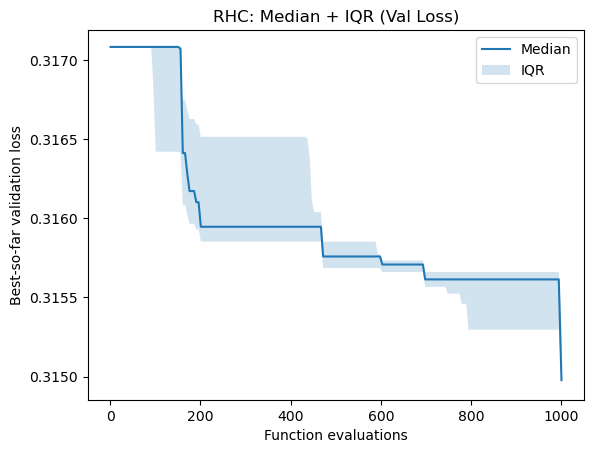

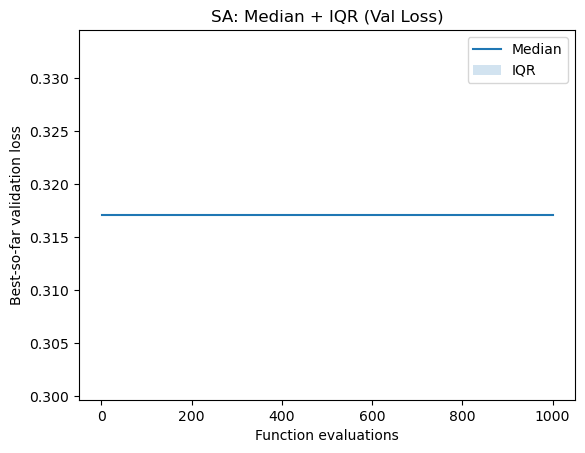

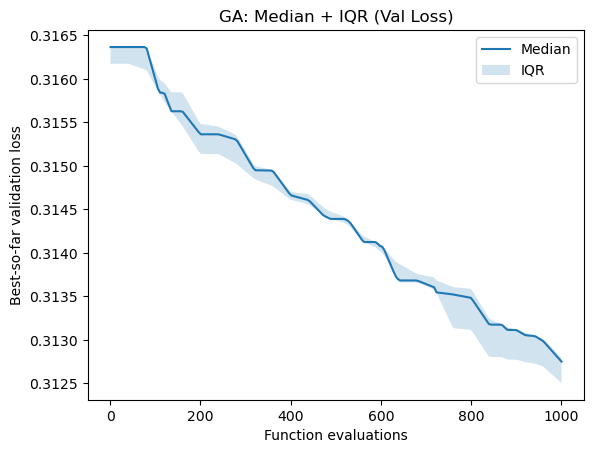

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_median_iqr(runs, method, budget):
    """
    Plot median and IQR of best-so-far validation loss versus function evaluations for a given RO method
    
    Input:
        runs (list[dict]): list of run dictionaries returned by run_ro_method
        method (str): method name to filter
        budget (int): maximum number of function evaluations

    Return: None
    """
    method_runs = [r for r in runs if r["method"] == method]
    
    grid = np.linspace(1, budget, 200).astype(int)
    
    Ys = []
    for r in method_runs:
        h = r["hist"].drop_duplicates("fevals").sort_values("fevals")
        y_interp = np.interp(grid, h["fevals"].values, h["best_val_loss"].values)
        Ys.append(y_interp)
    
    Ys = np.vstack(Ys)
    
    median = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, median, label="Median")
    plt.fill_between(grid, q1, q3, alpha=0.2, label="IQR")
    plt.xlabel("Function evaluations")
    plt.ylabel("Best-so-far validation loss")
    plt.title(f"{method}: Median + IQR (Val Loss)")
    plt.legend()
    plt.show()


for m in ["RHC", "SA", "GA"]:
    plot_median_iqr(runs, m, BUDGET_FEVALS)

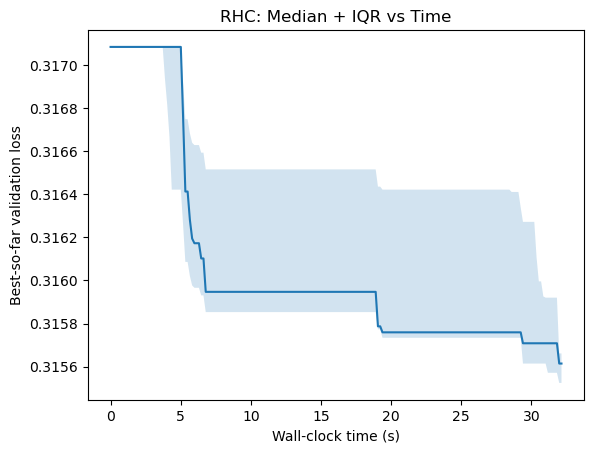

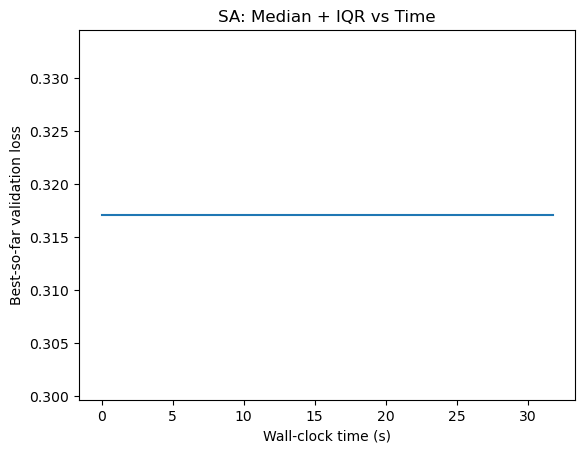

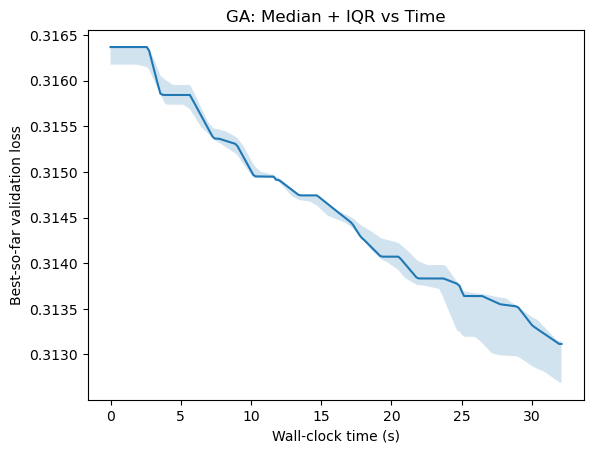

In [21]:
def plot_median_iqr_time(runs, method):
    """
    Plot median and IQR of best-so-far validation loss versus wall-clock time for a given RO method

    Input:
        runs (list[dict]): list of run dictionaries returned by run_ro_method
        method (str): method name to filter

    Return: None
    """
    method_runs = [r for r in runs if r["method"] == method]
    
    max_time = min(r["hist"]["time_s"].max() for r in method_runs)
    grid = np.linspace(0, max_time, 200)
    
    Ys = []
    for r in method_runs:
        h = r["hist"].drop_duplicates("time_s").sort_values("time_s")
        y_interp = np.interp(grid, h["time_s"].values, h["best_val_loss"].values)
        Ys.append(y_interp)
    
    Ys = np.vstack(Ys)
    
    median = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, median)
    plt.fill_between(grid, q1, q3, alpha=0.2)
    plt.xlabel("Wall-clock time (s)")
    plt.ylabel("Best-so-far validation loss")
    plt.title(f"{method}: Median + IQR vs Time")
    plt.show()


for m in ["RHC", "SA", "GA"]:
    plot_median_iqr_time(runs, m)

In [22]:
model.load_state_dict(baseline_state)
baseline_f1 = eval_f1(model, test_loader)
print("Baseline Test F1:", baseline_f1)

final_results = []

for method in ["RHC", "SA", "GA"]:
    method_runs = [r for r in runs if r["method"] == method]
    
    best_run = min(method_runs, key=lambda x: x["best_val_loss"])
    
    model.load_state_dict(baseline_state)
    model.unfreeze_last_k(k=chosen_k)
    assign_flattened_trainable(model, best_run["best_x"])
    
    test_f1 = eval_f1(model, test_loader)
    
    final_results.append({
        "method": method,
        "best_val_loss": float(best_run["best_val_loss"]),
        "test_f1": float(test_f1),
        "seed": int(best_run["seed"]),
        "func_evals": int(best_run.get("final_fevals", np.nan)),
        "time_s": float(best_run.get("final_time_s", np.nan)),
    })

df = pd.DataFrame(final_results)
df

Baseline Test F1: 0.6829035339063992


,method,best_val_loss,test_f1,seed,func_evals,time_s
0,RHC,0.314942,0.666828,49,1000,63.312540
1,SA,0.317084,0.682904,49,1000,42.575638
2,GA,0.312261,0.671565,11,1000,32.109400


## PART 2

In [23]:
@torch.no_grad()
def evaluate_all(model, train_loader, val_loader):
    """
    Evaluate a model on both train and validation splits

    Input:
        model (torch.nn.Module): neural network model to evaluate
        train_loader (DataLoader): DataLoader for training split evaluation
        val_loader (DataLoader): DataLoader for validation split evaluation

    Return:
        dict: dictionary containing average loss on the training and validation split (float), and F1 score on the training and validation split (float)
    """
    return {
        "train_loss": eval_loss(model, train_loader),
        "val_loss":   eval_loss(model, val_loader),
        "train_f1":   eval_f1(model, train_loader),
        "val_f1":     eval_f1(model, val_loader),
    }

def train_budgeted(make_model_fn, make_optimizer_fn, train_loader, val_loader, seed, grad_budget = 2000, eval_every = 100, l_thresh = None):
    """
    Train a model under a fixed gradient update budget and periodically evaluate

    Input:
        make_model_fn (callable): zero-argument function that returns a new model instance
        make_optimizer_fn (callable): function that takes model.parameters() and returns an optimizer
        train_loader (DataLoader): training DataLoader used for updates
        val_loader (DataLoader): validation DataLoader used for evaluation only
        seed (int): random seed for reproducibility
        grad_budget (int): maximum number of gradient update steps
        eval_every (int): evaluation frequency in steps
        l_thresh (float or None): validation loss threshold

    Return:
        model (torch.nn.Module): trained model at the end of the budget
        hist (pd.DataFrame): training log
        steps_to_l (int or None): first step where val_loss <= l_thresh
        time_to_l (float or None): elapsed time when val_loss first reaches l_thresh
        final (dict): final metrics dictionary
    """
    set_all_seeds(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = make_model_fn().to(device)
    optimizer = make_optimizer_fn(model.parameters())

    history = []
    steps_to_l = None
    time_to_l = None

    t0 = time.time()
    step = 0
    train_iter = iter(train_loader)

    metrics0 = evaluate_all(model, train_loader, val_loader)
    history.append({"step": 0, "time_s": 0.0, **metrics0})

    while step < grad_budget:
        try:
            xb, yb = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            xb, yb = next(train_iter)

        xb = xb.to(device); yb = yb.to(device)

        model.train()
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

        step += 1

        if (step % eval_every == 0) or (step == grad_budget):
            t = time.time() - t0
            metrics = evaluate_all(model, train_loader, val_loader)
            history.append({"step": step, "time_s": t, **metrics})

            if (l_thresh is not None) and (steps_to_l is None):
                if metrics["val_loss"] <= l_thresh:
                    steps_to_l = step
                    time_to_l = t

    hist = pd.DataFrame(history)
    final = hist.iloc[-1].to_dict()
    return model, hist, steps_to_l, time_to_l, final

In [24]:
input_dim = X_train_nn.shape[1]  

def make_model():
    """
    Build the baseline binary classification MLP model
    
    Input: None
    
    Return:
        torch.nn.Module: instantiated MLP_tmp model
    """
    return MLP_tmp(d=input_dim, h=128)

def make_adam_baseline(params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
    """
    Construct the standard Adam optimizer

    Input:
        params (iterable): model parameters to optimize
        lr (float): learning rate
        betas (tuple[float, float]): Adam beta coefficients (beta1, beta2)
        eps (float): numerical stability constant
        weight_decay (float): coupled L2 weight decay

    Return:
        torch.optim.Optimizer: Adam optimizer instance
    """
    return torch.optim.Adam(params, lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)


BASE_SEED = 49
BASE_BUDGET = 2000
_, hist_base, _, _, _ = train_budgeted(
    make_model_fn=make_model,
    make_optimizer_fn=lambda p: make_adam_baseline(p, lr=1e-3),
    train_loader=train_loader,
    val_loader=val_loader,
    seed=BASE_SEED,
    grad_budget=BASE_BUDGET,
    eval_every=100,
    l_thresh=None
)

baseline_min = hist_base["val_loss"].min()
L_THRESH = float(baseline_min + 0.005)
print("Baseline min val loss:", baseline_min)
print("Chosen L_THRESH:", L_THRESH)

Baseline min val loss: 0.3162681263828868
Chosen L_THRESH: 0.3212681263828868


In [25]:
from torch.optim.optimizer import Optimizer
import torch

class AdamNoBiasCorrection(Optimizer):
    """
    Adam optimizer variant without bias correction
    """
    def __init__(self, params, lr=1e-3, betas=(0.9,0.999), eps=1e-8, weight_decay=0.0):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        """
        Perform a single optimization step

        Input:
            closure (callable or None): optional closure that reevaluates the model and returns the loss

        Return:
            float or None: loss value returned by closure 
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            eps = group["eps"]
            wd = group["weight_decay"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad

                if wd != 0.0:
                    g = g.add(p, alpha=wd)

                state = self.state[p]
                if len(state) == 0:
                    state["m"] = torch.zeros_like(p)
                    state["v"] = torch.zeros_like(p)

                m = state["m"]
                v = state["v"]

                m.mul_(beta1).add_(g, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(g, g, value=1 - beta2)

                # No bias correction
                p.addcdiv_(m, v.sqrt().add_(eps), value=-lr)

        return loss

In [26]:
def tune_lr_one_seed(make_model_fn, make_opt_fn_from_lr, lr_grid, seed, train_loader, val_loader, grad_budget, eval_every):
    """
    Tune learning rate for a given model family using a single seed
    
    Input:
        make_model_fn (callable): returns a fresh model instance
        make_opt_fn_from_lr (callable): returns optimizer
        lr_grid (iterable[float]): candidate learning rates to evaluate
        seed (int): random seed for reproducibility
        train_loader (DataLoader): training DataLoader
        val_loader (DataLoader): validation DataLoader
        grad_budget (int): maximum number of gradient update steps
        eval_every (int): evaluation frequency in steps

    Return:
        best_lr (float): learning rate achieving lowest final validation loss
        df (pd.DataFrame): results table
    """
    
    rows = []
    for lr in lr_grid:
        ret = train_budgeted(
            make_model_fn=make_model_fn,
            make_optimizer_fn=lambda params, lr=lr: make_opt_fn_from_lr(params, lr),
            train_loader=train_loader,
            val_loader=val_loader,
            seed=seed,
            grad_budget=grad_budget,
            eval_every=eval_every,
            l_thresh=None
        )

        if isinstance(ret, tuple):
            final = ret[-1]
        else:
            final = ret

        rows.append({
            "lr": lr,
            "val_loss": float(final["val_loss"]),
            "val_f1": float(final.get("val_f1", np.nan)),
        })

    df = pd.DataFrame(rows).sort_values("val_loss")
    best_lr = float(df.iloc[0]["lr"])
    return best_lr, df

In [27]:
SGD_LR_GRID = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
MOM_LR_GRID = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
MOMENTUM = 0.9
TUNE_SEED_SGD = 49
GRAD_BUDGET = 1000   
EVAL_EVERY = 100


best_lr_sgd, df_lr_sgd = tune_lr_one_seed(
    make_model_fn=make_model,
    make_opt_fn_from_lr=lambda params, lr: torch.optim.SGD(params, lr=lr),
    lr_grid=SGD_LR_GRID,
    seed=TUNE_SEED_SGD,
    train_loader=train_loader,
    val_loader=val_loader,
    grad_budget=GRAD_BUDGET,
    eval_every=EVAL_EVERY
)

best_lr_mom, df_lr_mom = tune_lr_one_seed(
    make_model_fn=make_model,
    make_opt_fn_from_lr=lambda params, lr: torch.optim.SGD(params, lr=lr, momentum=MOMENTUM),
    lr_grid=MOM_LR_GRID,
    seed=TUNE_SEED_SGD,
    train_loader=train_loader,
    val_loader=val_loader,
    grad_budget=GRAD_BUDGET,
    eval_every=EVAL_EVERY
)

best_lr_nes, df_lr_nes = tune_lr_one_seed(
    make_model_fn=make_model,
    make_opt_fn_from_lr=lambda params, lr: torch.optim.SGD(params, lr=lr, momentum=MOMENTUM, nesterov=True),
    lr_grid=MOM_LR_GRID,
    seed=TUNE_SEED_SGD,
    train_loader=train_loader,
    val_loader=val_loader,
    grad_budget=GRAD_BUDGET,
    eval_every=EVAL_EVERY
)

print("Best lr SGD:", best_lr_sgd)
print("Best lr Momentum:", best_lr_mom)
print("Best lr Nesterov:", best_lr_nes)

display(df_lr_sgd)
display(df_lr_mom)
display(df_lr_nes)

Best lr SGD: 0.1
Best lr Momentum: 0.03
Best lr Nesterov: 0.01


,lr,val_loss,val_f1
4,0.100,0.319907,0.695287
3,0.030,0.328908,0.662774
2,0.010,0.358784,0.606557
1,0.003,0.443269,0.140984
0,0.001,0.518255,0.000000


,lr,val_loss,val_f1
3,0.030,0.317897,0.699539
2,0.010,0.319638,0.657908
4,0.100,0.321688,0.673902
1,0.003,0.328790,0.656863
0,0.001,0.359375,0.598442


,lr,val_loss,val_f1
2,0.010,0.319973,0.696680
3,0.030,0.321667,0.692343
4,0.100,0.323372,0.694161
1,0.003,0.329210,0.642785
0,0.001,0.359243,0.605128


In [28]:
SEEDS_P2 = [49, 35, 11]    
GRAD_BUDGET = 1000          
EVAL_EVERY = 100       

required_optimizers = [
    ("SGD",            lambda params: torch.optim.SGD(params, lr=best_lr_sgd)),
    ("SGD+Mom",        lambda params: torch.optim.SGD(params, lr=best_lr_mom, momentum=MOMENTUM)),
    ("Nesterov",       lambda params: torch.optim.SGD(params, lr=best_lr_nes, momentum=MOMENTUM, nesterov=True)),
    ("Adam",           lambda params: torch.optim.Adam(params, lr=1e-3, betas=(0.9, 0.999))),
    ("Adam(noBC)",     lambda params: AdamNoBiasCorrection(params, lr=1e-3, betas=(0.9, 0.999))),
    ("Adam(b1=0)",     lambda params: torch.optim.Adam(params, lr=1e-3, betas=(0.0, 0.999))),
    ("AdamW",          lambda params: torch.optim.AdamW(params, lr=1e-3, betas=(0.9, 0.999), weight_decay=1e-2)),
]

p2_runs = []

for opt_name, opt_fn in required_optimizers:
    for s in SEEDS_P2:
        model, hist, steps_to_L, time_to_L, final = train_budgeted(
            make_model_fn=make_model,
            make_optimizer_fn=opt_fn,
            train_loader=train_loader,
            val_loader=val_loader,
            seed=s,
            grad_budget=GRAD_BUDGET,
            eval_every=EVAL_EVERY,
            l_thresh=L_THRESH
        )

        p2_runs.append({
            "optimizer": opt_name,
            "seed": s,
            "steps_to_L": steps_to_L,
            "time_to_L_s": time_to_L,
            "final_train_loss": float(final["train_loss"]),
            "final_val_loss": float(final["val_loss"]),
            "final_train_f1": float(final["train_f1"]),
            "final_val_f1": float(final["val_f1"]),
            "hist": hist
        })

df_p2 = pd.DataFrame([{k:v for k,v in r.items() if k != "hist"} for r in p2_runs])
df_p2.sort_values(["optimizer","seed"])

,optimizer,seed,steps_to_L,time_to_L_s,final_train_loss,final_val_loss,final_train_f1,final_val_f1
11,Adam,11,400,2.750390,0.309078,0.318187,0.680780,0.684998
10,Adam,35,300,2.102992,0.311798,0.322230,0.698641,0.705830
9,Adam,49,600,4.490097,0.308090,0.317648,0.687975,0.690926
17,Adam(b1=0),11,500,3.229562,0.309017,0.316884,0.680742,0.678952
16,Adam(b1=0),35,400,2.739503,0.308306,0.317043,0.683197,0.692308
15,Adam(b1=0),49,400,2.683376,0.309634,0.318808,0.675439,0.677088
14,Adam(noBC),11,300,1.924225,0.306698,0.316338,0.692276,0.697740
13,Adam(noBC),35,200,1.496889,0.304438,0.317499,0.688814,0.698006
12,Adam(noBC),49,300,1.937293,0.306730,0.318046,0.670469,0.664650
20,AdamW,11,400,4.476847,0.308783,0.317348,0.675582,0.670617


In [29]:
opt_fn_map = {name: fn for (name, fn) in required_optimizers}

best_idx = df_p2.groupby("optimizer")["final_val_loss"].idxmin()
df_p2_best = df_p2.loc[best_idx].copy().reset_index(drop=True)

test_f1_list = []
best_val_loss_list = []
time_to_L_list = []

for _, row in df_p2_best.iterrows():
    opt_name = row["optimizer"]
    seed = int(row["seed"])
    opt_fn = opt_fn_map[opt_name]

    model2, hist2, steps_to_L2, time_to_L2, final2 = train_budgeted(
        make_model_fn=make_model,
        make_optimizer_fn=opt_fn,
        train_loader=train_loader,
        val_loader=val_loader,
        seed=seed,
        grad_budget=GRAD_BUDGET,
        eval_every=EVAL_EVERY,
        l_thresh=L_THRESH
    )

    test_f1_list.append(float(eval_f1(model2, test_loader)))
    best_val_loss_list.append(float(final2["val_loss"]))
    time_to_L_list.append(time_to_L2)

df_p2_best["best_val_loss"] = best_val_loss_list
df_p2_best["test_f1"] = test_f1_list
df_p2_best["time_to_L_s"] = time_to_L_list

df_p2_best[["optimizer","seed","best_val_loss","test_f1","time_to_L_s"]].sort_values("optimizer")

,optimizer,seed,best_val_loss,test_f1,time_to_L_s
0,Adam,49,0.321677,0.690625,3.215150
1,Adam(b1=0),11,0.317868,0.653730,3.281651
2,Adam(noBC),11,0.317387,0.685393,1.271812
3,AdamW,11,0.318895,0.659246,2.599458
4,Nesterov,11,0.321421,0.675024,5.288133
5,SGD,35,0.320381,0.655928,4.951693
6,SGD+Mom,35,0.320227,0.646774,4.341140


In [30]:
import numpy as np

df_p2_agg = df_p2.groupby("optimizer").agg(
    val_loss_median=("final_val_loss","median"),
    val_loss_iqr=("final_val_loss", lambda x: np.quantile(x,0.75)-np.quantile(x,0.25)),
    steps_to_L_median=("steps_to_L", lambda x: np.nanmedian([v if v is not None else np.nan for v in x])),
    time_to_L_median=("time_to_L_s", lambda x: np.nanmedian([v if v is not None else np.nan for v in x])),
    val_f1_median=("final_val_f1","median"),
    val_f1_iqr=("final_val_f1", lambda x: np.quantile(x,0.75)-np.quantile(x,0.25)),
).reset_index()

df_p2_agg.sort_values("val_loss_median")

,optimizer,val_loss_median,val_loss_iqr,steps_to_L_median,time_to_L_median,val_f1_median,val_f1_iqr
1,Adam(b1=0),0.317043,0.000962,400.0,2.739503,0.678952,0.007610
2,Adam(noBC),0.317499,0.000854,300.0,1.924225,0.697740,0.016678
3,AdamW,0.318091,0.000956,500.0,4.476847,0.701852,0.017169
0,Adam,0.318187,0.002291,400.0,2.750390,0.690926,0.010416
6,SGD+Mom,0.318888,0.001375,500.0,5.628689,0.686118,0.009454
4,Nesterov,0.319156,0.000755,700.0,4.709290,0.679884,0.005263
5,SGD,0.320096,0.000257,800.0,5.031090,0.683484,0.009554


In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_traj_median_iqr(p2_runs, optimizer_name, ycol="val_loss"):
    """
    Plot median and IQR of a trajectory over gradient updates
    
    Input:
        p2_runs (list[dict]): list of optimizer run dictionaries, each containing "optimizer" and "hist"
        optimizer_name (str): optimizer label to filter
        ycol (str): metric column to plot

    Return: None
    """
    rs = [r for r in p2_runs if r["optimizer"] == optimizer_name]
    if len(rs) == 0:
        print("No runs for:", optimizer_name)
        return
    
    grid = rs[0]["hist"]["step"].values

    Ys = []
    for r in rs:
        h = r["hist"].sort_values("step")
        y = np.interp(grid, h["step"].values, h[ycol].values)
        Ys.append(y)

    Ys = np.vstack(Ys)
    med = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, med)
    plt.fill_between(grid, q1, q3, alpha=0.2)
    plt.xlabel("Gradient updates")
    plt.ylabel(ycol)
    plt.title(f"{optimizer_name}: {ycol} (median/IQR across seeds)")
    plt.show()

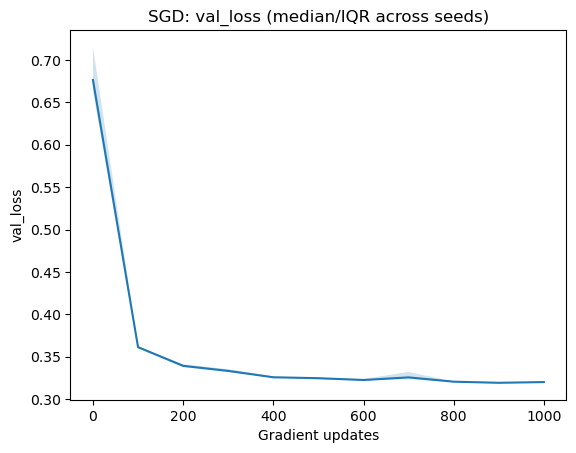

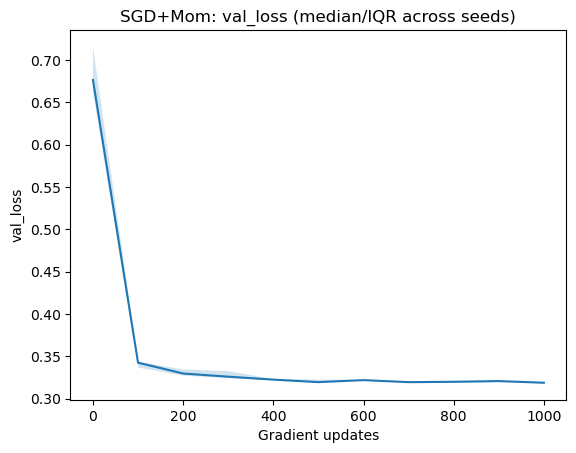

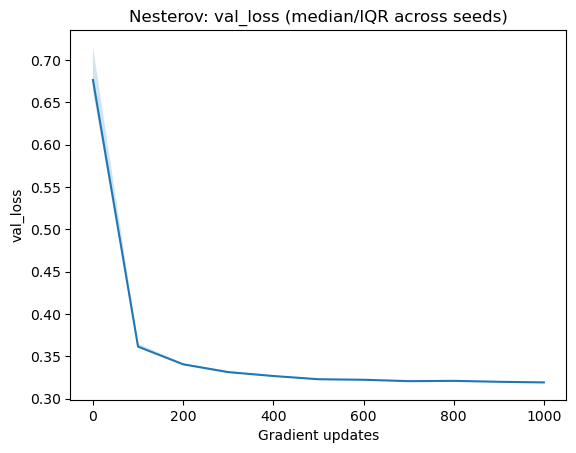

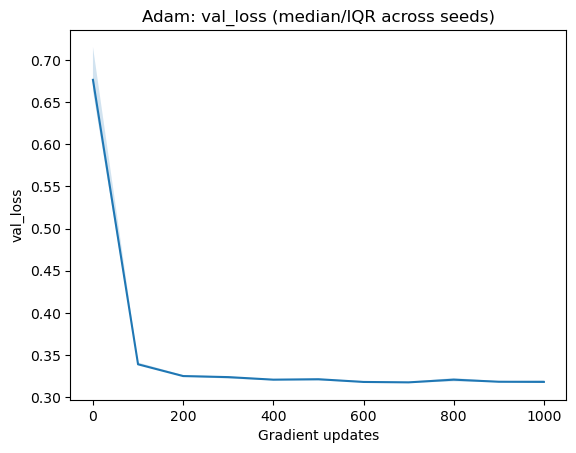

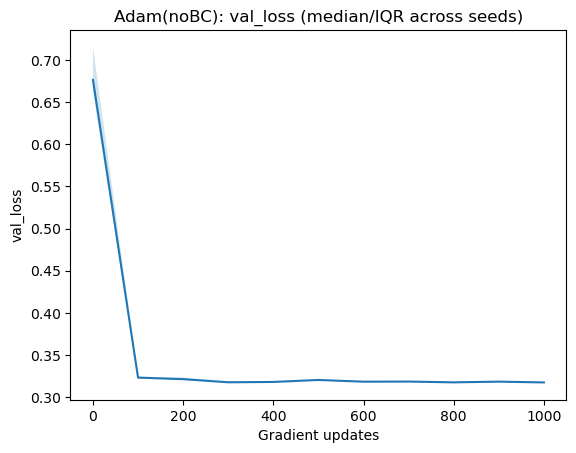

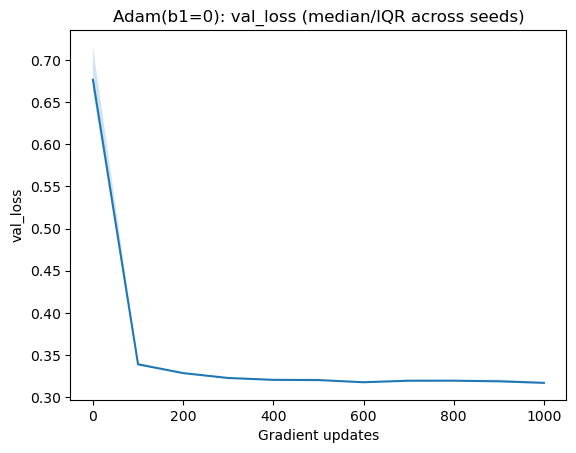

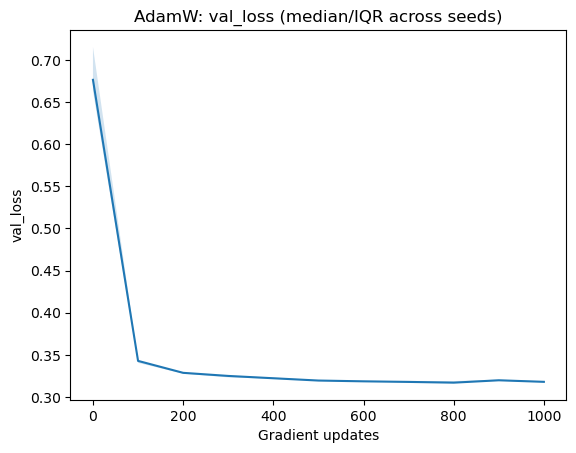

In [32]:
for opt_name, _ in required_optimizers:
    plot_traj_median_iqr(p2_runs, opt_name, ycol="val_loss")

In [33]:
def plot_traj_median_iqr_time(p2_runs, optimizer_name, ycol="val_loss", time_col="time_s"):
    """
    Plot median and IQR of a trajectory over wall-clock time

    Input:
        p2_runs (list[dict]): list of optimizer-run dictionaries, each containing "optimizer" and "hist"
        optimizer_name (str): optimizer label to filter
        ycol (str): metric column to plot
        time_col (str): time column name

    Return: None
    """
    rs = [r for r in p2_runs if r["optimizer"] == optimizer_name]
    if len(rs) == 0:
        print("No runs for:", optimizer_name)
        return

    end_times = [r["hist"][time_col].max() for r in rs]
    t_max = np.quantile(end_times, 0.95)
    grid = np.linspace(0, t_max, 200)

    Ys = []
    for r in rs:
        h = r["hist"].sort_values(time_col)
        y = np.interp(grid,
                      h[time_col].values,
                      h[ycol].values)
        Ys.append(y)

    Ys = np.vstack(Ys)
    med = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, med)
    plt.fill_between(grid, q1, q3, alpha=0.2)
    plt.xlabel("Wall-clock time (s)")
    plt.ylabel(ycol)
    plt.title(f"{optimizer_name}: {ycol} vs wall-clock (median/IQR)")
    plt.show()

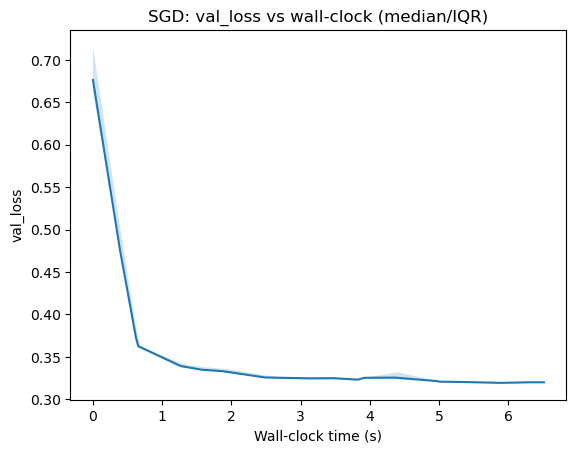

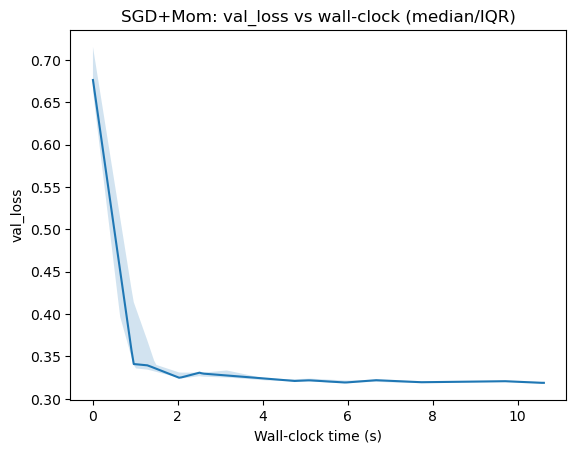

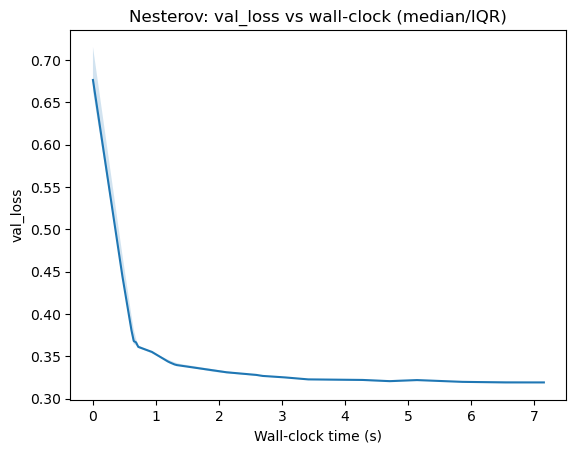

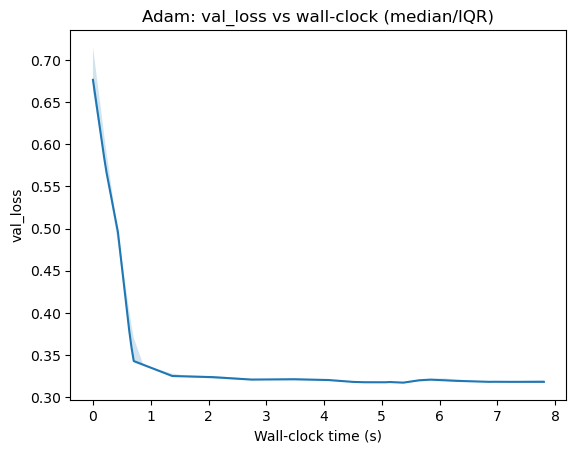

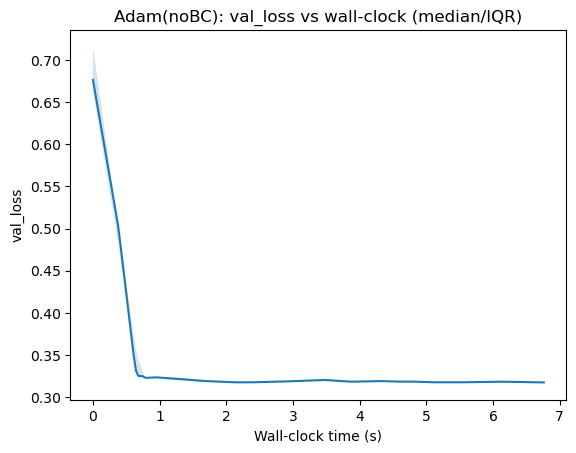

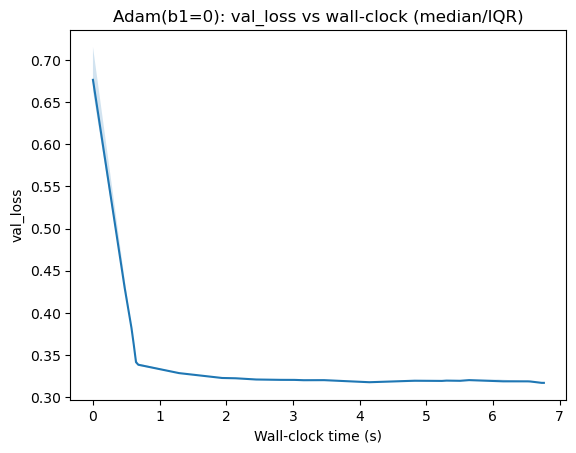

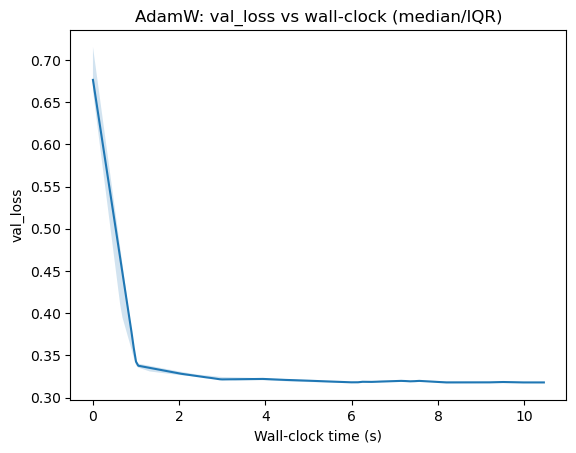

In [34]:
for opt_name, _ in required_optimizers:
    plot_traj_median_iqr_time(p2_runs, opt_name, ycol="val_loss")

### Heatmap 1: ($\alpha$, $\beta_1$) with fixed $\beta_2$ 

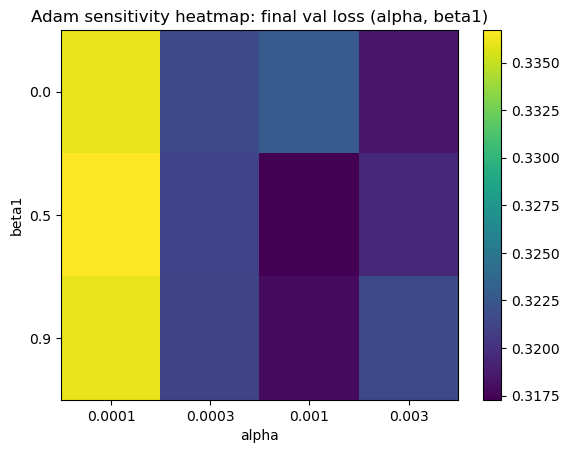

alpha,0.0001,0.0003,0.0010,0.0030
beta1,,,,
0.0,0.336038,0.321563,0.322880,0.318420
0.5,0.336708,0.321175,0.317281,0.319413
0.9,0.335996,0.321267,0.317859,0.321622


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HM_SEED = 49
HM_BUDGET = GRAD_BUDGET    
HM_EVAL_EVERY = EVAL_EVERY  

alphas = [1e-4, 3e-4, 1e-3, 3e-3]
beta1s = [0.0, 0.5, 0.9]
fixed_beta2 = 0.999

records = []
for a in alphas:
    for b1 in beta1s:
        _, _, _, _, final = train_budgeted(
            make_model_fn=make_model,
            make_optimizer_fn=lambda params, a=a, b1=b1: torch.optim.Adam(params, lr=a, betas=(b1, fixed_beta2)),
            train_loader=train_loader,
            val_loader=val_loader,
            seed=HM_SEED,
            grad_budget=HM_BUDGET,
            eval_every=HM_EVAL_EVERY,
            l_thresh=None
        )
        records.append({"alpha": a, "beta1": b1, "final_val_loss": float(final["val_loss"])})

df_hm_ab1 = pd.DataFrame(records)
pivot_ab1 = df_hm_ab1.pivot(index="beta1", columns="alpha", values="final_val_loss")

plt.figure()
plt.imshow(pivot_ab1.values, aspect="auto")
plt.xticks(range(len(alphas)), [str(x) for x in alphas])
plt.yticks(range(len(beta1s)), [str(x) for x in beta1s])
plt.xlabel("alpha")
plt.ylabel("beta1")
plt.title("Adam sensitivity heatmap: final val loss (alpha, beta1)")
plt.colorbar()
plt.show()

pivot_ab1

### Heatmap 2: ($\alpha$, $\beta_2$) with fixed $\beta_1$ 

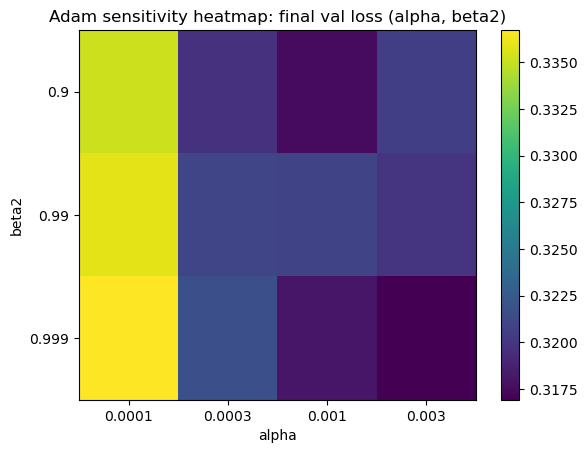

alpha,0.0001,0.0003,0.0010,0.0030
beta2,,,,
0.900,0.335233,0.319730,0.317497,0.320595
0.990,0.335895,0.321026,0.320946,0.319936
0.999,0.336736,0.321768,0.318101,0.316917


In [36]:
alphas = [1e-4, 3e-4, 1e-3, 3e-3]
beta2s = [0.9, 0.99, 0.999]
fixed_beta1 = 0.9

records = []
for a in alphas:
    for b2 in beta2s:
        _, _, _, _, final = train_budgeted(
            make_model_fn=make_model,
            make_optimizer_fn=lambda params, a=a, b2=b2: torch.optim.Adam(params, lr=a, betas=(fixed_beta1, b2)),
            train_loader=train_loader,
            val_loader=val_loader,
            seed=HM_SEED,
            grad_budget=HM_BUDGET,
            eval_every=HM_EVAL_EVERY,
            l_thresh=None
        )
        records.append({"alpha": a, "beta2": b2, "final_val_loss": float(final["val_loss"])})

df_hm_ab2 = pd.DataFrame(records)
pivot_ab2 = df_hm_ab2.pivot(index="beta2", columns="alpha", values="final_val_loss")

plt.figure()
plt.imshow(pivot_ab2.values, aspect="auto")
plt.xticks(range(len(alphas)), [str(x) for x in alphas])
plt.yticks(range(len(beta2s)), [str(x) for x in beta2s])
plt.xlabel("alpha")
plt.ylabel("beta2")
plt.title("Adam sensitivity heatmap: final val loss (alpha, beta2)")
plt.colorbar()
plt.show()

pivot_ab2

## PART 3

Using $\beta_1 = 0.9$, $\beta_2 = 0.99$ and $\alpha = 0.001$

In [37]:
class MLP_dropout(nn.Module):
    """
    MLP with dropout regularization for binary classification
    """
    def __init__(self, d, h, p_drop=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(d, h),
            nn.ReLU(),
            nn.Dropout(p_drop)
        )
        self.classifier = nn.Linear(h, 2)

    def forward(self, x):
        """
        Perform a forward pass through the network

        Input:
            x (torch.Tensor): input batch

        Return:
            torch.Tensor: raw logits
        """
        return self.classifier(self.features(x))

In [38]:
BEST_LR = 1e-3
BEST_BETAS = (0.9, 0.99)

def make_model_reg(p_drop=0.0):
    """
    Build the regularized MLP model with dropout

    Input:
        p_drop (float): dropout probability

    Return:
        torch.nn.Module: instantiated MLP_dropout model
    """
    return MLP_dropout(d=input_dim, h=128, p_drop=p_drop)

def make_adam(params, weight_decay=0.0):
    """
    Construct an Adam optimizer using the best hyperparameters found in Part 2.

    This helper uses BEST_LR and BEST_BETAS (selected from the Part 2 sweeps)
    and optionally applies coupled L2 weight decay.

    Input:
        params (iterable): model parameters to optimize
        weight_decay (float): coupled L2 weight decay coefficient

    Return:
        torch.optim.Optimizer: Adam optimizer instance
    """
    return torch.optim.Adam(params, lr=BEST_LR, betas=BEST_BETAS, weight_decay=weight_decay)

In [39]:
def train_budgeted_reg(make_model_fn, make_optimizer_fn, train_loader, val_loader, seed, grad_budget=2000, eval_every=100, patience_evals=5, min_delta=0.0, input_noise_std=0.0, label_smoothing=0.0):
    """
    Train a model under a fixed gradient update budget with optional regularization and early stopping
    
    Input:
        make_model_fn (callable): returns a new model instance
        make_optimizer_fn (callable): returns an optimizer
        train_loader (DataLoader): training DataLoader used for gradient updates
        val_loader (DataLoader): validation DataLoader used for evaluation only
        seed (int): random seed for reproducibility
        grad_budget (int): maximum number of gradient update steps
        eval_every (int): evaluation frequency in steps
        patience_evals (int): early stopping patience measured in evaluation checkpoints
        min_delta (float): minimum improvement in validation loss required to reset patience
        input_noise_std (float): standard deviation of Gaussian noise added to inputs during training
        label_smoothing (float): label smoothing parameter for CrossEntropyLoss

    Return:
        model (torch.nn.Module): trained model restored to best validation checkpoint
        hist (pd.DataFrame): training log
        final (dict): final metrics dictionary 
    """
    set_all_seeds(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = make_model_fn().to(device)
    optimizer = make_optimizer_fn(model.parameters())

    train_criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    best_state = None
    best_val = float("inf")
    bad_count = 0

    history = []
    t0 = time.time()
    step = 0
    train_iter = iter(train_loader)

    metrics0 = {
        "train_loss": eval_loss(model, train_loader),
        "val_loss": eval_loss(model, val_loader),
        "train_f1": eval_f1(model, train_loader),
        "val_f1": eval_f1(model, val_loader),
    }
    history.append({"step": 0, "time_s": 0.0, **metrics0})
    best_val = metrics0["val_loss"]
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    while step < grad_budget:
        try:
            xb, yb = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            xb, yb = next(train_iter)

        xb = xb.to(device)
        yb = yb.to(device)

        if input_noise_std > 0.0:
            xb = xb + torch.randn_like(xb) * input_noise_std

        model.train()
        optimizer.zero_grad()
        loss = train_criterion(model(xb), yb) 
        loss.backward()
        optimizer.step()

        step += 1

        if (step % eval_every == 0) or (step == grad_budget):
            t = time.time() - t0
            metrics = {
                "train_loss": eval_loss(model, train_loader),
                "val_loss": eval_loss(model, val_loader),
                "train_f1": eval_f1(model, train_loader),
                "val_f1": eval_f1(model, val_loader),
            }
            history.append({"step": step, "time_s": t, **metrics})

            if metrics["val_loss"] < best_val - min_delta:
                best_val = metrics["val_loss"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience_evals:
                    break

    model.load_state_dict(best_state)

    hist = pd.DataFrame(history)
    final = hist.iloc[-1].to_dict()
    return model, hist, final

In [40]:
import pandas as pd
import numpy as np

TUNE_SEED = 49
P3_BUDGET = 1000
EVAL_EVERY = 100

def run_cfg_once(weight_decay=0.0, p_drop=0.0, noise_std=0.0, label_smoothing=0.0, early_stop=False, patience=5):
    """
    Run a single regularization configuration using one seed

    Input:
        weight_decay (float): coupled L2 weight decay coefficient
        p_drop (float): dropout probability for MLP_dropout
        noise_std (float): input noise standard deviation
        label_smoothing (float): label smoothing parameter
        early_stop (bool): whether to enable early stopping
        patience (int): early stopping patience

    Return:
        val_loss (float): final validation loss
        val_f1 (float): final validation F1 score
    """
    model, hist, final = train_budgeted_reg(
        make_model_fn=lambda: make_model_reg(p_drop=p_drop),
        make_optimizer_fn=lambda params: make_adam(params, weight_decay=weight_decay),
        train_loader=train_loader,
        val_loader=val_loader,
        seed=TUNE_SEED,
        grad_budget=P3_BUDGET,
        eval_every=EVAL_EVERY,
        patience_evals=patience if early_stop else 10_000,
        min_delta=0.0,
        input_noise_std=noise_std, 
        label_smoothing=label_smoothing
    )
    return float(final["val_loss"]), float(final["val_f1"])

tune_rows = []

# Weight decay sweep
for wd in [0.0, 1e-5, 1e-4, 1e-3, 1e-2]:
    vl, vf1 = run_cfg_once(weight_decay=wd)
    tune_rows.append({"reg": "weight_decay", "value": wd, "val_loss": vl, "val_f1": vf1})

# Dropout sweep
for p in [0.0, 0.1, 0.2, 0.3, 0.5]:
    vl, vf1 = run_cfg_once(p_drop=p)
    tune_rows.append({"reg": "dropout", "value": p, "val_loss": vl, "val_f1": vf1})

# Noise sweep
for ns in [0.0, 0.005, 0.01, 0.02]:
    vl, vf1 = run_cfg_once(noise_std=ns)
    tune_rows.append({"reg": "noise", "value": ns, "val_loss": vl, "val_f1": vf1})

# Early stopping sweep
for pat in [3, 5, 8]:
    vl, vf1 = run_cfg_once(early_stop=True, patience=pat)
    tune_rows.append({"reg": "early_stop", "value": pat, "val_loss": vl, "val_f1": vf1})
    
# Label smoothing sweep
for ls in [0.0, 0.02, 0.05, 0.1]:
    vl, vf1 = run_cfg_once(label_smoothing=ls)
    tune_rows.append({"reg": "label_smoothing", "value": ls, "val_loss": vl, "val_f1": vf1})

df_tune = pd.DataFrame(tune_rows).sort_values(["reg","val_loss"])
df_tune

,reg,value,val_loss,val_f1
7,dropout,0.20000,0.316658,0.692344
5,dropout,0.00000,0.317570,0.683802
6,dropout,0.10000,0.317575,0.674498
8,dropout,0.30000,0.318740,0.695331
9,dropout,0.50000,0.318943,0.672861
14,early_stop,3.00000,0.315742,0.691651
16,early_stop,8.00000,0.317318,0.695817
15,early_stop,5.00000,0.317908,0.701021
17,label_smoothing,0.00000,0.316654,0.693079
18,label_smoothing,0.02000,0.317709,0.672628


In [41]:
best_per_reg = df_tune.sort_values("val_loss").groupby("reg").head(1)
best_per_reg

best_wd = float(best_per_reg.loc[best_per_reg["reg"]=="weight_decay","value"].values[0])
best_p  = float(best_per_reg.loc[best_per_reg["reg"]=="dropout","value"].values[0])
best_ns = float(best_per_reg.loc[best_per_reg["reg"]=="noise","value"].values[0])
best_pat= int(best_per_reg.loc[best_per_reg["reg"]=="early_stop","value"].values[0])
best_ls = float(best_per_reg.loc[best_per_reg["reg"]=="label_smoothing","value"].values[0])

best_wd, best_p, best_ns, best_pat, best_ls

(0.0, 0.2, 0.0, 3, 0.0)

In [42]:
SEEDS_P3 = [49, 35, 11]

def run_cfg_multi(name, weight_decay=0.0, p_drop=0.0, noise_std=0.0, label_smoothing=0.0, early_stop=False, patience=5, return_hist=False):
    """
    Run a regularization configuration across multiple seeds

    Input:
        name (str): label for the regularization configuration
        weight_decay (float): coupled L2 weight decay coefficient
        p_drop (float): dropout probability
        noise_std (float): input noise standard deviation
        label_smoothing (float): label smoothing parameter
        early_stop (bool): whether to enable early stopping
        patience (int): early stopping patience 
        return_hist (bool): if True, include the hist per seed

    Return:
        list[dict]: list of result rows, one per seed
    """
    out = []
    for s in SEEDS_P3:
        model, hist, final = train_budgeted_reg(
            make_model_fn=lambda: make_model_reg(p_drop=p_drop),
            make_optimizer_fn=lambda params: make_adam(params, weight_decay=weight_decay),
            train_loader=train_loader,
            val_loader=val_loader,
            seed=s,
            grad_budget=P3_BUDGET,
            eval_every=EVAL_EVERY,
            patience_evals=patience if early_stop else 10_000,
            min_delta=0.0,
            input_noise_std=noise_std, 
            label_smoothing=label_smoothing
        )
        row = {
            "reg": name,
            "seed": s,
            "final_val_loss": float(final["val_loss"]),
            "final_val_f1": float(final["val_f1"])
        }
        if return_hist:
            row["hist"] = hist
        out.append(row)
    return out

p3_confirm = []
p3_confirm += run_cfg_multi("baseline", weight_decay=0.0, p_drop=0.0, noise_std=0.0, label_smoothing=0.0, early_stop=False, patience=5, return_hist=True)
p3_confirm += run_cfg_multi(f"weight_decay({best_wd})", weight_decay=best_wd, p_drop=0.0, noise_std=0.0, label_smoothing=0.0,early_stop=False, patience=5, return_hist=True)
p3_confirm += run_cfg_multi(f"dropout({best_p})", weight_decay=0.0, p_drop=best_p, noise_std=0.0, label_smoothing=0.0,early_stop=False, patience=5, return_hist=True)
p3_confirm += run_cfg_multi(f"noise({best_ns})", weight_decay=0.0, p_drop=0.0, noise_std=best_ns, label_smoothing=0.0,early_stop=False, patience=5, return_hist=True)
p3_confirm += run_cfg_multi(f"label_smoothing({best_ls})", weight_decay=0.0, p_drop=0.0, noise_std=0.0, label_smoothing=best_ls,early_stop=False, patience=5, return_hist=True)
p3_confirm += run_cfg_multi(f"early_stop(pat={best_pat})", weight_decay=0.0, p_drop=0.0, noise_std=0.0, label_smoothing=0.0,early_stop=True, patience=best_pat, return_hist=True)

df_p3_confirm = pd.DataFrame([{k:v for k,v in r.items() if k!="hist"} for r in p3_confirm])
df_p3_confirm

,reg,seed,final_val_loss,final_val_f1
0,baseline,49,0.317524,0.696148
1,baseline,35,0.318942,0.678970
2,baseline,11,0.315894,0.685604
3,weight_decay(0.0),49,0.318296,0.668322
4,weight_decay(0.0),35,0.319112,0.666999
5,weight_decay(0.0),11,0.315508,0.682193
6,dropout(0.2),49,0.316825,0.687954
7,dropout(0.2),35,0.317415,0.675235
8,dropout(0.2),11,0.316763,0.691393
9,noise(0.0),49,0.316798,0.685851


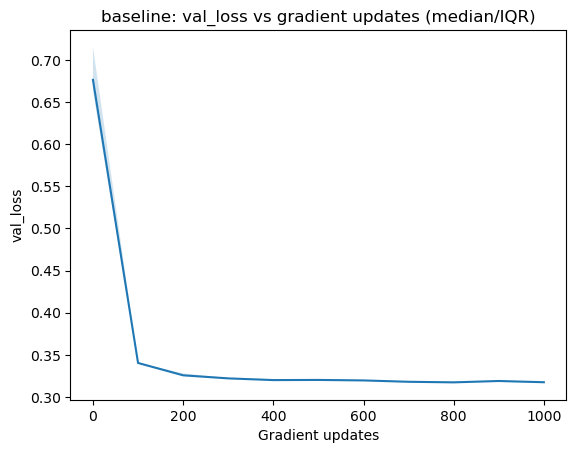

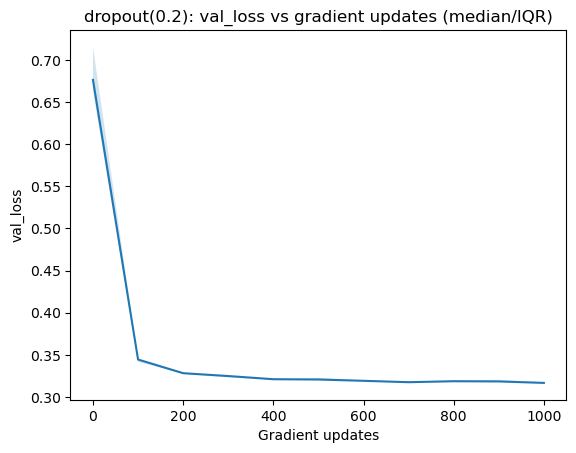

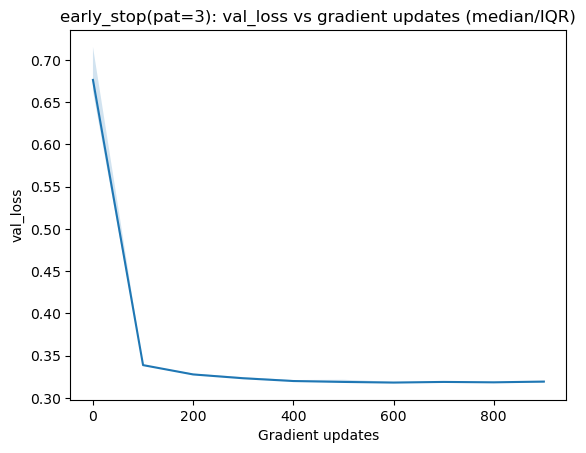

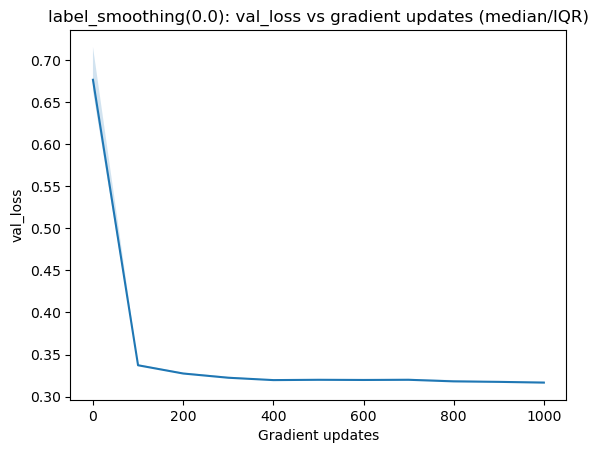

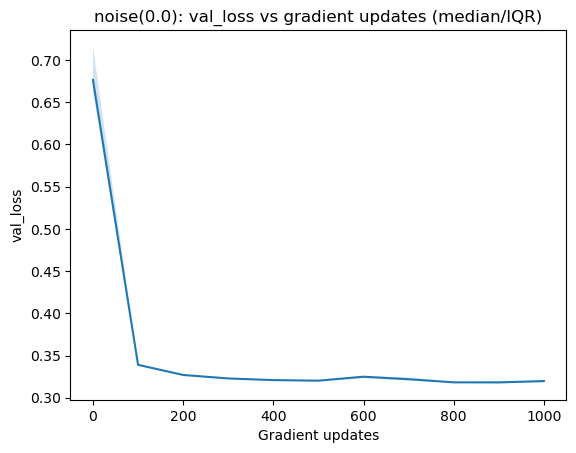

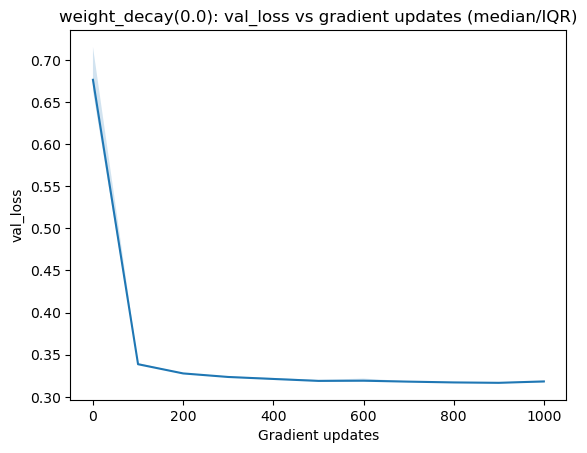

In [43]:
def plot_traj_median_iqr_p3(p3_runs_traj, reg_name, ycol="val_loss"):
    """
    Plot median and IQR trajectory over gradient updates for Part 3 regularization runs

    Input:
        p3_runs_traj (list[dict]): list of run dictionaries containing "reg" and "hist"
        reg_name (str): regularization configuration name to filter
        ycol (str): metric column to plot

    Return: None
    """
    rs = [r for r in p3_runs_traj if r["reg"] == reg_name]
    if len(rs) == 0:
        print("No runs for:", reg_name)
        return

    grid = rs[0]["hist"]["step"].values

    Ys = []
    for r in rs:
        h = r["hist"].sort_values("step")
        y = np.interp(grid, h["step"].values, h[ycol].values)
        Ys.append(y)

    Ys = np.vstack(Ys)
    med = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, med)
    plt.fill_between(grid, q1, q3, alpha=0.2)
    plt.xlabel("Gradient updates")
    plt.ylabel(ycol)
    plt.title(f"{reg_name}: {ycol} vs gradient updates (median/IQR)")
    plt.show()

for reg in sorted(set(r["reg"] for r in p3_confirm)):
    plot_traj_median_iqr_p3(p3_confirm, reg, ycol="val_loss")

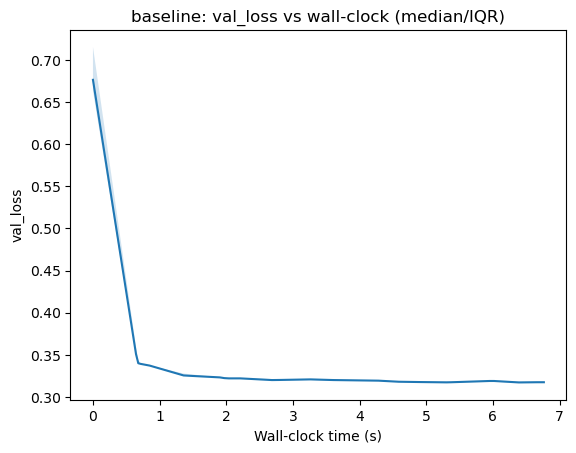

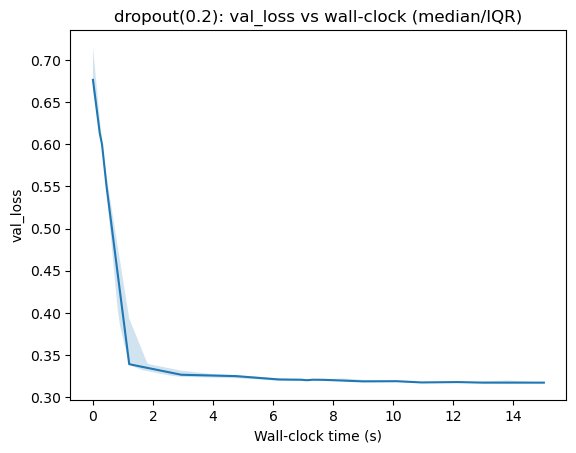

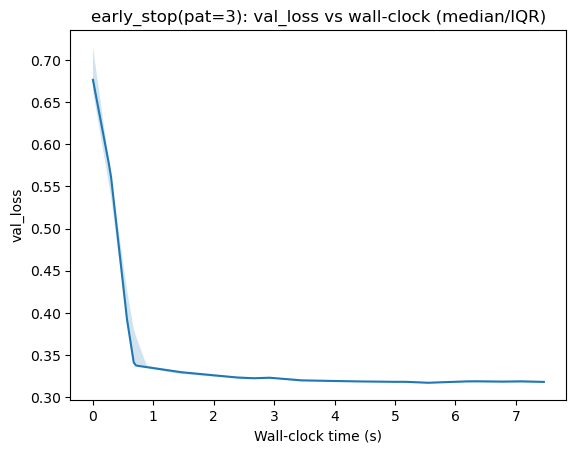

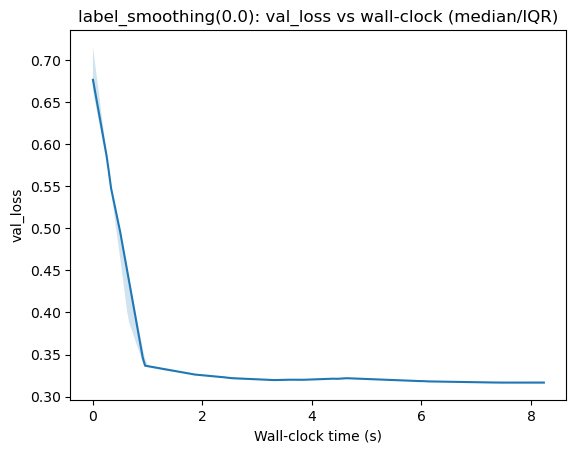

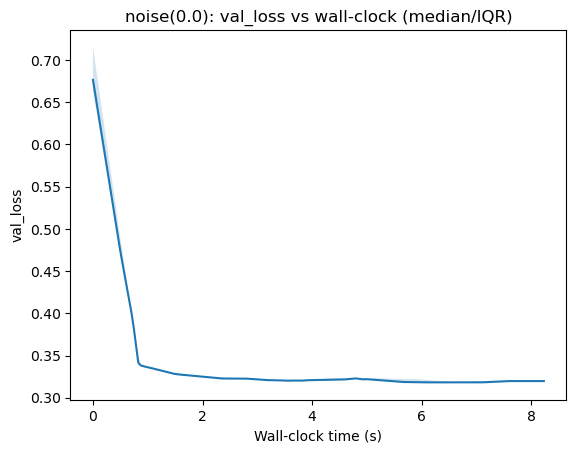

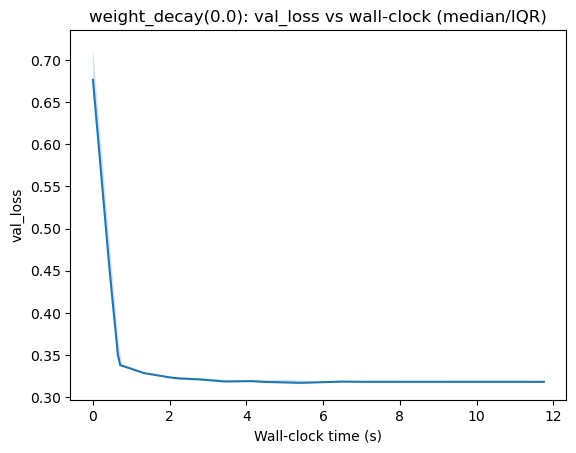

In [44]:
def plot_traj_median_iqr_time_p3(p3_runs_traj, reg_name, ycol="val_loss", time_col="time_s"):
    """
    Plot median and IQR trajectory over wall-clock time for Part 3 regularization runs

    Input:
        p3_runs_traj (list[dict]): list of run dictionaries containing "reg" and "hist"
        reg_name (str): regularization configuration name to filter
        ycol (str): metric column to plot
        time_col (str): time column name

    Return: None
    """
    
    rs = [r for r in p3_runs_traj if r["reg"] == reg_name]
    if len(rs) == 0:
        print("No runs for:", reg_name)
        return

    end_times = [r["hist"][time_col].max() for r in rs]
    t_max = np.quantile(end_times, 0.95)
    grid = np.linspace(0, t_max, 200)

    Ys = []
    for r in rs:
        h = r["hist"].sort_values(time_col)
        y = np.interp(grid, h[time_col].values, h[ycol].values)
        Ys.append(y)

    Ys = np.vstack(Ys)
    med = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, med)
    plt.fill_between(grid, q1, q3, alpha=0.2)
    plt.xlabel("Wall-clock time (s)")
    plt.ylabel(ycol)
    plt.title(f"{reg_name}: {ycol} vs wall-clock (median/IQR)")
    plt.show()

for reg in sorted(set(r["reg"] for r in p3_confirm)):
    plot_traj_median_iqr_time_p3(p3_confirm, reg, ycol="val_loss", time_col="time_s")

In [45]:
df_p3_confirm_agg = df_p3_confirm.groupby("reg").agg(
    val_loss_median=("final_val_loss","median"),
    val_loss_iqr=("final_val_loss", lambda x: np.quantile(x,0.75)-np.quantile(x,0.25)),
    val_f1_median=("final_val_f1","median"),
    val_f1_iqr=("final_val_f1", lambda x: np.quantile(x,0.75)-np.quantile(x,0.25)),
).reset_index().sort_values("val_loss_median")

df_p3_confirm_agg

,reg,val_loss_median,val_loss_iqr,val_f1_median,val_f1_iqr
3,label_smoothing(0.0),0.316678,0.001549,0.682903,0.013223
1,dropout(0.2),0.316825,0.000326,0.687954,0.008079
0,baseline,0.317524,0.001524,0.685604,0.008589
2,early_stop(pat=3),0.318227,0.001807,0.692823,0.013606
5,weight_decay(0.0),0.318296,0.001802,0.668322,0.007597
4,noise(0.0),0.319749,0.001654,0.685851,0.012458


In [46]:
p3_combo = []
p3_combo += run_cfg_multi(f"combo(wd={best_wd},drop={best_p})", weight_decay=best_wd, p_drop=best_p, noise_std=0.0, label_smoothing=0.0, early_stop=False, patience=5)
p3_combo += run_cfg_multi(f"combo(wd={best_wd},drop={best_p},ls={best_ls})",weight_decay=best_wd, p_drop=best_p, noise_std=0.0, label_smoothing=best_ls,early_stop=False, patience=5)
p3_combo += run_cfg_multi(f"combo(wd={best_wd},drop={best_p},ES={best_pat})",weight_decay=best_wd, p_drop=best_p, noise_std=0.0, label_smoothing=0.0,early_stop=True, patience=best_pat)
p3_combo += run_cfg_multi(f"combo(wd={best_wd},drop={best_p},ls={best_ls},ES={best_pat})",weight_decay=best_wd, p_drop=best_p, noise_std=0.0, label_smoothing=best_ls,early_stop=True, patience=best_pat)

df_p3_combo = pd.DataFrame(p3_combo)

df_p3_combo_agg = df_p3_combo.groupby("reg").agg(
    val_loss_median=("final_val_loss","median"),
    val_loss_iqr=("final_val_loss", lambda x: np.quantile(x,0.75)-np.quantile(x,0.25)),
    val_f1_median=("final_val_f1","median"),
    val_f1_iqr=("final_val_f1", lambda x: np.quantile(x,0.75)-np.quantile(x,0.25)),
).reset_index().sort_values("val_loss_median")

df_p3_combo_agg

,reg,val_loss_median,val_loss_iqr,val_f1_median,val_f1_iqr
2,"combo(wd=0.0,drop=0.2,ls=0.0)",0.318428,0.000589,0.688355,0.012166
1,"combo(wd=0.0,drop=0.2,ES=3)",0.318904,0.002049,0.671260,0.002292
3,"combo(wd=0.0,drop=0.2,ls=0.0,ES=3)",0.318932,0.001178,0.684814,0.009809
0,"combo(wd=0.0,drop=0.2)",0.318998,0.001063,0.686753,0.023414


In [47]:
df_single_rank = df_p3_confirm_agg.copy()

fake = {"noise(0.0)", "weight_decay(0.0)", f"dropout(0.0)", f"label_smoothing(0.0)"}
df_single_rank_real = df_single_rank[~df_single_rank["reg"].isin(fake)].copy()

df_single_rank_real = df_single_rank_real[df_single_rank_real["reg"] != "baseline"]

best_single_real = df_single_rank_real.sort_values("val_loss_median").iloc[0]["reg"]
print("Best SINGLE regularizer (excluding 0.0 and baseline):", best_single_real)

best_combo = df_p3_combo_agg.sort_values("val_loss_median").iloc[0]["reg"]
print("Best COMBO:", best_combo)

Best SINGLE regularizer (excluding 0.0 and baseline): dropout(0.2)
Best COMBO: combo(wd=0.0,drop=0.2,ls=0.0)


In [48]:
FINAL_SEED = 49

def run_and_test(weight_decay=0.0, p_drop=0.0, noise_std=0.0, label_smoothing=0.0, early_stop=False, patience=5):
    """
    Train a regularization configuration using one seed and evaluate test F1

    Input:
        weight_decay (float): coupled L2 weight decay coefficient
        p_drop (float): dropout probability
        noise_std (float): input noise standard deviation
        label_smoothing (float): label smoothing parameter
        early_stop (bool): whether to enable early stopping
        patience (int): early stopping patience

    Return:
        final_val_loss (float): final validation loss from the training log
        test_f1 (float): F1 score computed on the test set
    """
    model, hist, final = train_budgeted_reg(
        make_model_fn=lambda: make_model_reg(p_drop=p_drop),
        make_optimizer_fn=lambda params: make_adam(params, weight_decay=weight_decay),
        train_loader=train_loader,
        val_loader=val_loader,
        seed=FINAL_SEED,
        grad_budget=P3_BUDGET,
        eval_every=EVAL_EVERY,
        patience_evals=patience if early_stop else 10_000,
        min_delta=0.0,
        input_noise_std=noise_std,
        label_smoothing=label_smoothing
    )
    test_f1 = eval_f1(model, test_loader)
    return float(final["val_loss"]), float(test_f1)

val_base, test_base = run_and_test(weight_decay=0.0, p_drop=0.0, noise_std=0.0, early_stop=False)
print("Baseline -> val_loss:", val_base, "| test_f1:", test_base)

if best_combo == f"combo(wd={best_wd},drop={best_p})":
    val_combo, test_combo = run_and_test(weight_decay=best_wd, p_drop=best_p, noise_std=0.0, label_smoothing=0.0,early_stop=False)
elif best_combo == f"combo(wd={best_wd},drop={best_p},ls={best_ls})":
    val_combo, test_combo = run_and_test(weight_decay=best_wd, p_drop=best_p, noise_std=0.0, label_smoothing=best_ls,early_stop=False)
elif best_combo == f"combo(wd={best_wd},drop={best_p},ES={best_pat})":
    val_combo, test_combo = run_and_test(weight_decay=best_wd, p_drop=best_p, noise_std=0.0, label_smoothing=0.0,early_stop=True, patience=best_pat)
elif best_combo == f"combo(wd={best_wd},drop={best_p},ls={best_ls},ES={best_pat})":
    val_combo, test_combo = run_and_test(weight_decay=best_wd, p_drop=best_p, noise_std=0.0, label_smoothing=best_ls,early_stop=True, patience=best_pat)
else:
    raise ValueError("Unexpected best_combo name: " + str(best_combo))

print("Best combo ->", best_combo, "val_loss:", val_combo, "| test_f1:", test_combo)

Baseline -> val_loss: 0.3161095027774144 | test_f1: 0.6751833451620535
Best combo -> combo(wd=0.0,drop=0.2,ls=0.0) val_loss: 0.3195029460676154 | test_f1: 0.6692142345354669


In [49]:
if "weight_decay" in best_single_real:
    wd = float(best_single_real.split("(")[1].replace(")", ""))
    val_single, test_single = run_and_test(weight_decay=wd)
elif "dropout" in best_single_real:
    p = float(best_single_real.split("(")[1].replace(")", ""))
    val_single, test_single = run_and_test(p_drop=p)
elif "label_smoothing" in best_single_real:
    ls = float(best_single_real.split("(")[1].replace(")", ""))
    val_single, test_single = run_and_test(label_smoothing=ls)
elif "noise" in best_single_real:
    ns = float(best_single_real.split("(")[1].replace(")", ""))
    val_single, test_single = run_and_test(noise_std=ns)
elif "early_stop" in best_single_real:
    pat = int(best_single_real.split("=")[1].replace(")", ""))
    val_single, test_single = run_and_test(early_stop=True, patience=pat)
else:
    raise ValueError("Unexpected best_single_real name: " + str(best_single_real))

print("Best single ->", best_single_real, "val_loss:", val_single, "| test_f1:", test_single)

Best single -> dropout(0.2) val_loss: 0.3191887848696929 | test_f1: 0.6509026188660056


In [50]:
p3_rows = []

p3_rows.append({"Method":"P3-Adam baseline", "Best Val Loss": float(val_base), "Test F1": float(test_base)})

p3_rows.append({"Method":f"P3-Best single: {best_single_real}", "Best Val Loss": float(val_single), "Test F1": float(test_single)})

p3_rows.append({"Method":f"P3-Best combo: {best_combo}", "Best Val Loss": float(val_combo), "Test F1": float(test_combo)})

df_p3 = pd.DataFrame(p3_rows)
df_p3

,Method,Best Val Loss,Test F1
0,P3-Adam baseline,0.316110,0.675183
1,P3-Best single: dropout(0.2),0.319189,0.650903
2,"P3-Best combo: combo(wd=0.0,drop=0.2,ls=0.0)",0.319503,0.669214


### Summary table

In [51]:
summary = []

summary.append({
    "Method": "Backbone baseline",
    "Best Val Loss": float(baseline_min),
    "Test Metric (F1)": float(baseline_f1),
    "Time to ℓ (s)": np.nan,
    "#Grad Evals": np.nan,
    "#Func Evals": np.nan,
    "Updates": np.nan
})

for _, r in df.iterrows():
    summary.append({
        "Method": f"RO-{r['method']}",
        "Best Val Loss": float(r["best_val_loss"]),
        "Test Metric (F1)": float(r["test_f1"]),
        "Time to ℓ (s)": np.nan,
        "#Grad Evals": 0,
        "#Func Evals": float(r["func_evals"]) if pd.notna(r["func_evals"]) else np.nan,
        "Updates": float(r["func_evals"]) if pd.notna(r["func_evals"]) else np.nan,
    })

for _, r in df_p2_best.iterrows():
    summary.append({
        "Method": f"P2-{r['optimizer']}",
        "Best Val Loss": float(r["best_val_loss"]),
        "Test Metric (F1)": float(r["test_f1"]),
        "Time to ℓ (s)": float(r["time_to_L_s"]) if pd.notna(r["time_to_L_s"]) else np.nan,
        "#Grad Evals": int(GRAD_BUDGET),
        "#Func Evals": 0,
        "Updates": int(GRAD_BUDGET)
    })

for _, r in df_p3.iterrows():
    summary.append({
        "Method": r["Method"],
        "Best Val Loss": float(r["Best Val Loss"]),
        "Test Metric (F1)": float(r["Test F1"]),
        "Time to ℓ (s)": np.nan, 
        "#Grad Evals": int(P3_BUDGET),
        "#Func Evals": 0,
        "Updates": int(P3_BUDGET)
    })

df_summary = pd.DataFrame(summary)
df_summary

,Method,Best Val Loss,Test Metric (F1),Time to ℓ (s),#Grad Evals,#Func Evals,Updates
0,Backbone baseline,0.316268,0.686093,NaN,NaN,NaN,NaN
1,RO-RHC,0.315543,0.661878,NaN,0.0,1000.0,1000.0
2,RO-SA,0.317230,0.672644,NaN,0.0,1000.0,1000.0
3,RO-GA,0.312538,0.671277,NaN,0.0,1000.0,1000.0
4,P2-Adam,0.321677,0.690625,3.215150,1000.0,0.0,1000.0
5,P2-Adam(b1=0),0.317868,0.653730,3.281651,1000.0,0.0,1000.0
6,P2-Adam(noBC),0.317387,0.685393,1.271812,1000.0,0.0,1000.0
7,P2-AdamW,0.318895,0.659246,2.599458,1000.0,0.0,1000.0
8,P2-Nesterov,0.321421,0.675024,5.288133,1000.0,0.0,1000.0
9,P2-SGD,0.320381,0.655928,4.951693,1000.0,0.0,1000.0
